In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('results/combined.csv')

In [6]:
def classify(row):
    ret = str(row['returned']).lower()
    exp = str(row['expected']).lower()
    if ret in ('true', 'false') and ret == exp:
        return 'right'
    elif ret in ('true', 'false'):
        return 'wrong'
    else:
        return 'unknown'

df['verdict'] = df.apply(classify, axis=1)

## Summary: right / wrong per config

In [7]:
summary = (
    df.groupby(['config', 'verdict'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['right', 'wrong', 'unknown'], fill_value=0)
)
summary

verdict,right,wrong,unknown
config,,,
bu.json,7,0,21
fwd.json,7,0,21
td3.json,10,0,18
wbu.json,7,0,21


## Cactus plot: tasks solved vs simulated timeout

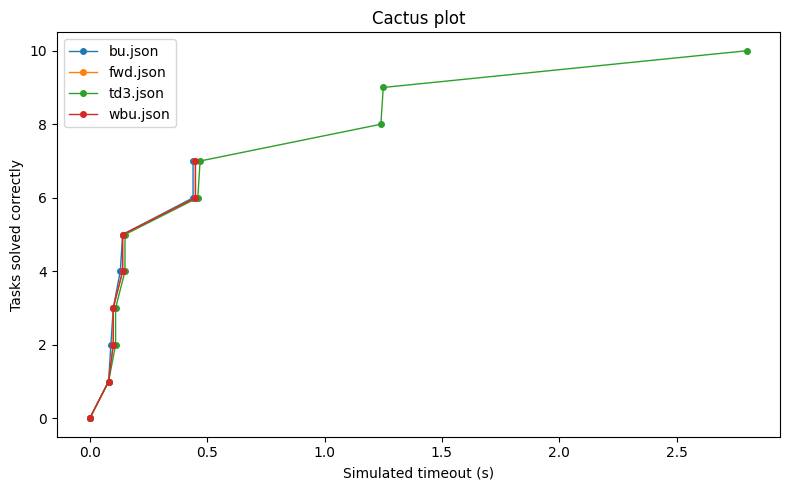

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for cfg, group in df.groupby('config'):
    right = group[group['verdict'] == 'right'].sort_values('runtime')
    xs = [0] + list(right['runtime'])
    ys = list(range(len(right) + 1))
    ax.plot(xs, ys, marker='o', markersize=4, linewidth=1, label=cfg)

ax.set_xlabel('Simulated timeout (s)')
ax.set_ylabel('Tasks solved correctly')
ax.set_title('Cactus plot')
ax.legend()
plt.tight_layout()
plt.show()